# Hand tracking demo - MediaPipe (local runtime)

This demo reads a [LeRobot](https://docs.daft.ai/en/stable/datasets/lerobot/) dataset, runs hand tracking (MediaPipe) as a Daft UDF with `track_hands`, and shows the keypoints. Every method returns the same schema: a list of `{handedness, confidence, kp2d, kp3d?}` per frame (`kp3d` is null for MediaPipe).

## Setup

Install with `pip install daft-physical-ai[mediapipe] matplotlib`, then import.

In [1]:
from daft.datasets import lerobot

from daft_physical_ai import track_hands

## Configure

The dataset, the camera column to decode, and how many frames to run.

In [2]:
DATASET = "pepijn223/egodex-test"
IMAGE_COLUMN = "observation.image"
LIMIT = 12

## Read the dataset

The LeRobot reader gives one row per frame, decoding the camera into an image column.

In [3]:
df = lerobot.read(DATASET, load_video_frames=IMAGE_COLUMN).limit(LIMIT)

## Track hands

`track_hands` returns a hand-pose column. It's a lazy, batched Daft UDF, so nothing runs until we materialize below.

In [4]:
df = df.with_column("hands", track_hands(df[IMAGE_COLUMN], method="mediapipe"))

## Inspect the results

`.show()` triggers execution and renders the keypoints per frame.

In [5]:
df.select("episode_index", "frame_index", "hands").show()

episode_indexInt64,frame_indexInt64,"handsList[Struct[handedness: String, confidence: Float32, kp2d: List[List[Float32]], kp3d: List[List[Float32]]]]"
0,0,"[{handedness: right,confidence: 0.9794173,kp2d: [[1412.1072, 1111.0558], [1357.8835, 1075.8923], [1311.5656, 1034.4496], [1260.7471, 1008.3797], [1220.5414, 985.66003], [1363.1233, 955.7938], [1304.561, 905.5346], [1260.0364, 904.46075], [1231.5793, 914.2655], [1371.448, 968.684], [1311.5648, 915.86176], [1267.3914, 911.2824], [1232.203, 919.9325], [1369.8796, 987.3212], [1319.4286, 946.88007], [1280.4844, 938.9859], [1247.1836, 944.724], [1367.7869, 1005.9669], [1323.2595, 980.48914], [1290.7727, 975.43243], [1260.3286, 977.2865]],kp3d: None,}, {handedness: right,confidence: 0.8413756,kp2d: [[955.5483, 1071.1882], [949.2257, 1010.06964], [974.78955, 963.06476], [1002.3847, 941.01984], [1022.8061, 921.33374], [994.69507, 930.244], [1031.2391, 900.4101], [1054.8162, 898.8746], [1073.7618, 903.1935], [1004.5198, 948.35944], [1031.0066, 924.41046], [1028.9314, 926.9088], [1027.941, 929.80505], [1013.6691, 962.03534], [1029.1893, 936.6315], [1019.47314, 942.6173], [1014.15765, 948.491], [1025.5225, 971.35455], [1024.8092, 952.5709], [1018.24023, 956.4652], [1011.2193, 960.43555]],kp3d: None,}]"
0,1,"[{handedness: right,confidence: 0.96713614,kp2d: [[1393.3395, 1109.6255], [1348.1707, 1069.8313], [1305.685, 1029.2609], [1259.4854, 998.9981], [1230.1556, 969.3371], [1368.9869, 956.0294], [1310.2391, 905.5856], [1264.3632, 900.70386], [1235.2386, 906.73145], [1375.427, 972.96814], [1314.6185, 921.28644], [1266.5918, 916.0787], [1228.7261, 924.74194], [1372.9783, 993.1551], [1318.684, 957.401], [1277.2979, 956.43036], [1244.8279, 964.8907], [1368.977, 1011.908], [1321.2949, 987.09985], [1290.1565, 983.9009], [1263.3112, 985.2774]],kp3d: None,}, {handedness: right,confidence: 0.7439953,kp2d: [[952.22327, 1074.6909], [957.5957, 1012.4505], [985.09894, 963.039], [1011.70245, 935.9921], [1030.7986, 915.94855], [998.2862, 931.3249], [1028.8302, 902.7634], [1049.686, 900.347], [1067.0027, 904.31757], [1003.813, 951.50354], [1026.5665, 928.04034], [1032.1115, 927.4797], [1037.9886, 930.45435], [1009.15454, 967.8328], [1025.9487, 942.4864], [1024.8501, 941.3562], [1024.669, 944.73816], [1017.65717, 980.9395], [1021.42706, 959.1198], [1021.0419, 957.7427], [1020.70026, 958.2971]],kp3d: None,}]"
0,2,"[{handedness: right,confidence: 0.9736023,kp2d: [[1411.5774, 1108.3651], [1356.6216, 1073.8838], [1311.4204, 1034.262], [1261.7875, 1008.15125], [1223.567, 987.3802], [1364.3497, 957.9176], [1308.4469, 904.83203], [1266.0961, 897.8199], [1237.3032, 900.95087], [1374.1666, 969.5267], [1317.3209, 914.8863], [1275.579, 904.9622], [1240.5465, 906.9157], [1373.6952, 987.0621], [1326.762, 945.54724], [1290.27, 933.62634], [1257.9252, 932.752], [1371.5061, 1004.49414], [1328.914, 978.2099], [1296.9497, 971.88434], [1266.6418, 972.0605]],kp3d: None,}, {handedness: right,confidence: 0.76208746,kp2d: [[956.03107, 1069.1648], [952.76135, 1010.4959], [976.89764, 962.788], [1003.67444, 939.5531], [1022.4893, 921.8757], [1002.3145, 933.9999], [1032.676, 904.1227], [1053.2357, 901.7682], [1072.6134, 903.83295], [1011.2299, 951.4002], [1028.2661, 924.8682], [1024.353, 928.72363], [1025.8857, 935.02893], [1017.74084, 963.3228], [1026.9275, 936.6354], [1017.9662, 941.9898], [1016.08154, 948.43195], [1026.5371, 971.1569], [1022.4575, 949.9096], [1016.3557, 953.32886], [1012.76904, 956.75134]],kp3d: None,}]"
0,3,"[{handedness: right,confidence: 0.9738133,kp2d: [[1403.5613, 1107.4369], [1349.0132, 1072.5704], [1305.811, 1032.9541], [1260.271, 1004.64185], [1225.4296, 979.4107], [1364.935, 952.81934], [1309.3556, 897.1172], [1265.1942, 892.97314], [1237.566, 901.2288], [1379.0238, 965.8892], [1319.3131, 909.2569], [1273.8578, 903.5918], [1238.6002, 912.36127], [1380.5214, 984.57245], [1327.283, 942.61633], [1286.1411, 935.32135], [1252.7616, 940.44696], [1379.192, 1002.8585], [1328.0236, 973.5865], [1293.3901, 967.54

## Visualize

Draw the predicted keypoints on a few frames - this is the point of hand tracking, so let's see it. (Needs `matplotlib`; `cv2` ships with the method extra.)

In [6]:
# --- Visualize: draw the predicted keypoints on a few frames ---
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 21-keypoint hand skeleton (wrist + 5 fingers x 4 joints)
BONES = [(0, 1), (1, 2), (2, 3), (3, 4), (0, 5), (5, 6), (6, 7), (7, 8),
         (0, 9), (9, 10), (10, 11), (11, 12), (0, 13), (13, 14), (14, 15),
         (15, 16), (0, 17), (17, 18), (18, 19), (19, 20)]


def draw_hands(img, hands):
    img = np.ascontiguousarray(img)
    for h in hands or []:
        kp = np.asarray(h["kp2d"], float)
        for a, b in BONES:
            cv2.line(img, tuple(kp[a].astype(int)), tuple(kp[b].astype(int)), (60, 200, 60), 2)
        for p in kp:
            cv2.circle(img, tuple(p.astype(int)), 3, (255, 80, 0), -1)
    return img

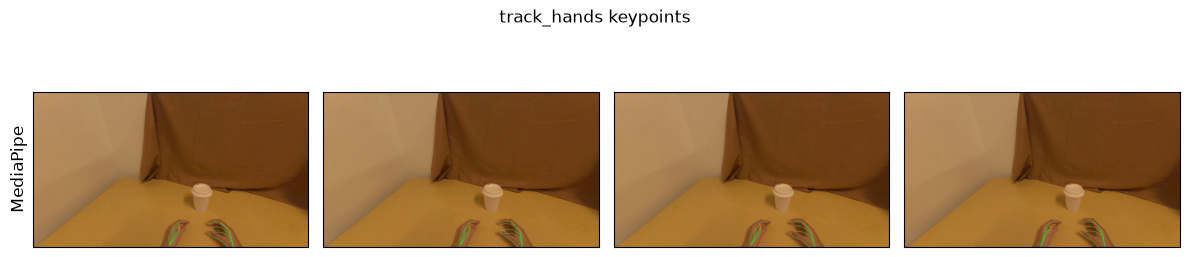

In [7]:
viz = df.select(IMAGE_COLUMN, "hands").limit(4).to_pydict()
frames = [np.asarray(im) for im in viz[IMAGE_COLUMN]]
methods = [("MediaPipe", "hands")]
fig, axes = plt.subplots(len(methods), len(frames), figsize=(3 * len(frames), 3 * len(methods)), squeeze=False)
for r, (label, c) in enumerate(methods):
    for j, (im, hands) in enumerate(zip(frames, viz[c])):
        axes[r][j].imshow(draw_hands(im, hands))
        axes[r][j].set_xticks([])
        axes[r][j].set_yticks([])
    axes[r][0].set_ylabel(label, fontsize=12)
fig.suptitle("track_hands keypoints")
plt.tight_layout()
plt.show()

## Evaluate against ground truth

EgoDex ships per-frame GT hand poses, so we can score the predictions: project both GT hands, match the predicted hands to them, and report detect% + PCK. The matching runs as a Daft UDF (`score`); the summary is computed from the collected results.

> EgoDex-specific (GT layout + camera intrinsics). Needs `pip install scipy`.

In [8]:
# --- Evaluation against EgoDex ground truth (2D, wrist + 5 fingertips) ---
# EgoDex-specific: GT hand poses live in observation.state (left = dims 0-23,
# right = 24-47); the camera is observation.extrinsics. Needs scipy + numpy.
import numpy as np
from scipy.optimize import linear_sum_assignment

import daft
from daft import DataType, col

FX = FY = 736.6339          # EgoDex camera intrinsics
CX, CY = 960.0, 540.0
SIX = [0, 4, 8, 12, 16, 20]  # wrist + 5 fingertip keypoints
THRESH = [0.1, 0.2, 0.3]     # PCK thresholds (normalized)


def _hand_pts(state, side):
    b = side * 24            # 24 dims per hand: wrist(3) + joints; we take wrist + 5 tips
    return np.vstack([state[b : b + 3], state[b + 9 : b + 24].reshape(5, 3)])


def _project(points_world, extr):
    cam_from_world = np.linalg.inv(np.asarray(extr, float).reshape(4, 4))
    cam = (cam_from_world @ np.hstack([points_world, np.ones((len(points_world), 1))]).T).T[:, :3]
    z = cam[:, 2]
    with np.errstate(divide="ignore", invalid="ignore"):
        uv = np.stack([FX * cam[:, 0] / z + CX, FY * cam[:, 1] / z + CY], axis=1)
    uv[z <= 0] = np.nan
    return uv


def _norm(p):               # translation + scale invariant (hand size)
    p = p - p[0]
    return p / (np.linalg.norm(p[1:], axis=1).mean() + 1e-9)


def _pair_err(gt6, pred6):  # per-keypoint error, fingertips matched by assignment
    g, m = _norm(gt6), _norm(pred6)
    d = np.linalg.norm(g[1:, None] - m[None, 1:], axis=2)
    r, c = linear_sum_assignment(d)
    return np.concatenate([[0.0], d[r, c]])


_ERR = DataType.struct({
    "n_gt": DataType.int64(),
    "n_matched": DataType.int64(),
    "errs": DataType.list(DataType.list(DataType.float64())),
})


@daft.func(return_dtype=_ERR)
def score(hands, state, extr):
    """Match predicted hands to the 2 GT hands (Hungarian on normalized error)."""
    gts = [uv for uv in (_project(_hand_pts(np.asarray(state, float), s), extr) for s in (0, 1)) if np.isfinite(uv).all()]
    preds = [np.asarray(h["kp2d"], float)[SIX] for h in (hands or [])]
    if not gts or not preds:
        return {"n_gt": len(gts), "n_matched": 0, "errs": []}
    pair = [[_pair_err(g, p) for p in preds] for g in gts]
    cost = np.array([[e.mean() for e in row] for row in pair])
    r, c = linear_sum_assignment(cost)   # match predicted hands to GT hands
    return {"n_gt": len(gts), "n_matched": len(r), "errs": [[float(x) for x in pair[i][j]] for i, j in zip(r, c)]}


def report(label, scores):
    n_gt = sum(s["n_gt"] for s in scores)
    matched = sum(s["n_matched"] for s in scores)
    errs = [e for s in scores for hand in s["errs"] for e in hand]
    mean_errs = [float(np.mean(hand)) for s in scores for hand in s["errs"]]
    pck = [100 * np.mean([e < t for e in errs]) if errs else 0.0 for t in THRESH]
    detect = 100 * matched / n_gt if n_gt else 0.0
    mean = float(np.mean(mean_errs)) if mean_errs else float("nan")
    print(f"{label:12} detect={detect:3.0f}%  mean_err={mean:.3f}  "
          f"PCK@.1/.2/.3 = {pck[0]:.0f}/{pck[1]:.0f}/{pck[2]:.0f}")

In [9]:
df = df.with_column("score_hands", score(col("hands"), col("observation.state"), col("observation.extrinsics")))
scored = df.select("score_hands").to_pydict()

In [10]:
print("EgoDex 2D accuracy:")
report("MediaPipe", scored["score_hands"])

EgoDex 2D accuracy:
MediaPipe    detect=100%  mean_err=0.105  PCK@.1/.2/.3 = 54/88/97
